# Exercise 3: Dense Network for Regression — Solution

In this exercise, you will build a fully connected neural network to solve a **regression** task using the California Housing dataset. Unlike classification (Exercise 2), the network will predict a **continuous value** (median house price).

You will learn:
- How to create a custom PyTorch `Dataset` for tabular data
- How regression differs from classification (loss function, output layer, metrics)
- How to evaluate regression with MSE, MAE, and R²
- How to visualize predictions vs. ground truth

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **1. Data Loading and Exploration**

The [California Housing dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) contains 20,640 samples with 8 features each (e.g., median income, house age, average rooms). The target is the **median house value** (in units of $100,000).

In [17]:
# Load dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

print(f"Feature names: {housing.feature_names}")
print(f"Input shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")
print(f"Target mean: {y.mean():.2f}, std: {y.std():.2f}")

# Remove capped outliers: the dataset clips house values at $500k (5.001)
# This creates a large spike of samples at exactly 5.0, which distorts training
mask = y < 5.0
X, y = X[mask], y[mask]
print(f"\nAfter removing capped values (target >= 5.0):")
print(f"Remaining samples: {X.shape[0]}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Input shape: (20640, 8)
Target shape: (20640,)
Target range: [0.15, 5.00]
Target mean: 2.07, std: 1.15

After removing capped values (target >= 5.0):
Remaining samples: 19648
Target range: [0.15, 4.99]


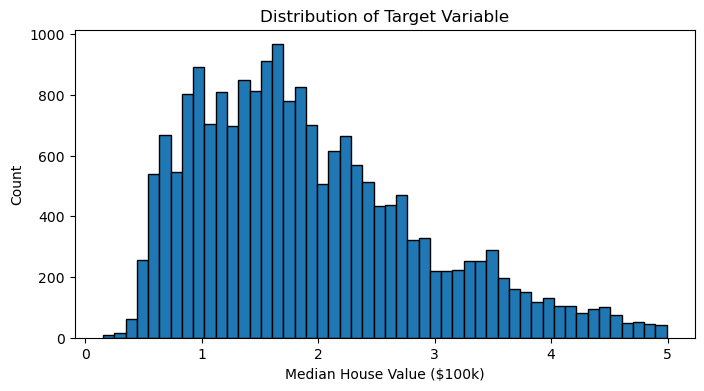

In [18]:
# Visualize target distribution
plt.figure(figsize=(8, 4))
plt.hist(y, bins=50, edgecolor='black')
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Count')
plt.title('Distribution of Target Variable')
plt.show()

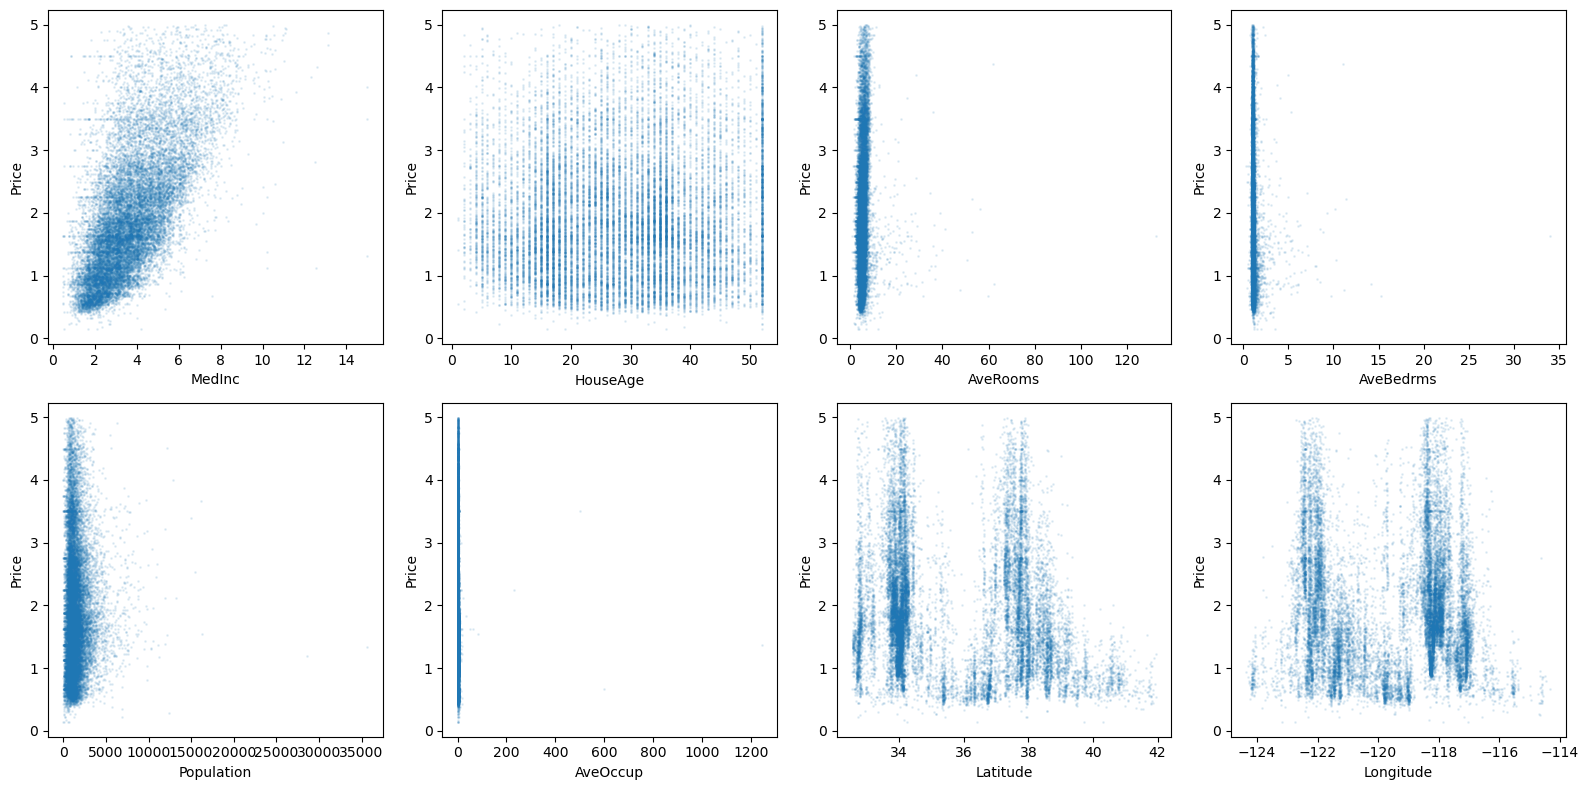

In [19]:
# Visualize relationship between each feature and the target
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (ax, name) in enumerate(zip(axes.ravel(), housing.feature_names)):
    ax.scatter(X[:, i], y, alpha=0.1, s=1)
    ax.set_xlabel(name)
    ax.set_ylabel('Price')
plt.tight_layout()
plt.show()

# **2. Data Preprocessing**

For regression with neural networks, it is important to **standardize** the input features (zero mean, unit variance). This helps the optimizer converge faster.

We also split the data into **train / validation / test** sets (60% / 20% / 20%).

In [20]:
# Split into train+val and test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Split train+val into train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 11788 | Val: 3930 | Test: 3930


In [21]:
# Standardize features (fit on train, transform all splits)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train feature mean: {X_train.mean(axis=0).round(2)}")
print(f"Train feature std:  {X_train.std(axis=0).round(2)}")

Train feature mean: [ 0.  0. -0.  0.  0. -0.  0.  0.]
Train feature std:  [1. 1. 1. 1. 1. 1. 1. 1.]


# **3. Custom PyTorch Dataset**

Unlike image datasets (MNIST, CIFAR), tabular data is not available through `torchvision`. You need to create a custom `Dataset` class.

A custom Dataset must implement:
- `__len__()`: returns the number of samples
- `__getitem__(idx)`: returns a single sample (features, target) at index `idx`

In [22]:
class HousingDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

In [23]:
# Parameters
batch_size = 64
num_epochs = 50
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Create datasets
train_dataset = HousingDataset(X_train, y_train)
val_dataset = HousingDataset(X_val, y_val)
test_dataset = HousingDataset(X_test, y_test)

# Create dataloaders
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Sanity check
sample_features, sample_target = next(iter(trainloader))
print(f"Batch features shape: {sample_features.shape}")
print(f"Batch target shape: {sample_target.shape}")

Using device: cuda:0
Batch features shape: torch.Size([64, 8])
Batch target shape: torch.Size([64, 1])


# **4. Define Regression Model**

Build a dense network for regression. Key differences from classification:
- The **output layer** has a single neuron (predicting one continuous value)
- **No softmax or activation** on the output (we want an unbounded real number)

Suggested architecture: `8 → 128 → 64 → 32 → 1` with ReLU activations between hidden layers.

In [24]:
class RegressionNet(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.dense1 = nn.Linear(input_features, 128)
        self.dense2 = nn.Linear(128, 64)
        self.dense3 = nn.Linear(64, 32)
        self.dense4 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.dense1(x))
        x = torch.relu(self.dense2(x))
        x = torch.relu(self.dense3(x))
        x = self.dense4(x)
        return x

# **5. Training Loop**

For regression, we use **Mean Squared Error (MSE)** as the loss function instead of Cross-Entropy.

Use the **Adam** optimizer (generally converges faster than SGD for regression tasks).

**Question:** Why is CrossEntropyLoss not suitable for regression?

In [25]:
# Instantiate model, loss, and optimizer
input_features = X_train.shape[1]  # 8 features

model = RegressionNet(input_features).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params}")

RegressionNet(
  (dense1): Linear(in_features=8, out_features=128, bias=True)
  (dense2): Linear(in_features=128, out_features=64, bias=True)
  (dense3): Linear(in_features=64, out_features=32, bias=True)
  (dense4): Linear(in_features=32, out_features=1, bias=True)
)
Total trainable parameters: 11521


In [26]:
# Training loop with validation
best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # ---- Training phase ----
    model.train()
    running_loss = 0.0
    for batch_features, batch_targets in trainloader:
        # Put data on device
        batch_features = batch_features.to(device)
        batch_targets = batch_targets.to(device)

        # Forward pass
        predictions = model(batch_features)
        loss = criterion(predictions, batch_targets)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_features.size(0)

    train_loss = running_loss / len(trainloader.dataset)
    train_losses.append(train_loss)

    # ---- Validation phase ----
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for batch_features, batch_targets in valloader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)
            predictions = model(batch_features)
            loss = criterion(predictions, batch_targets)
            running_loss += loss.item() * batch_features.size(0)

    val_loss = running_loss / len(valloader.dataset)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), './best_regression_model.pth')

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

print('Finished Training')

Epoch   1/50 | Train Loss: 0.8802 | Val Loss: 0.3985
Epoch  10/50 | Train Loss: 0.2532 | Val Loss: 0.2683
Epoch  20/50 | Train Loss: 0.2241 | Val Loss: 0.2409
Epoch  30/50 | Train Loss: 0.2144 | Val Loss: 0.2284
Epoch  40/50 | Train Loss: 0.2049 | Val Loss: 0.2578
Epoch  50/50 | Train Loss: 0.1963 | Val Loss: 0.2215
Finished Training


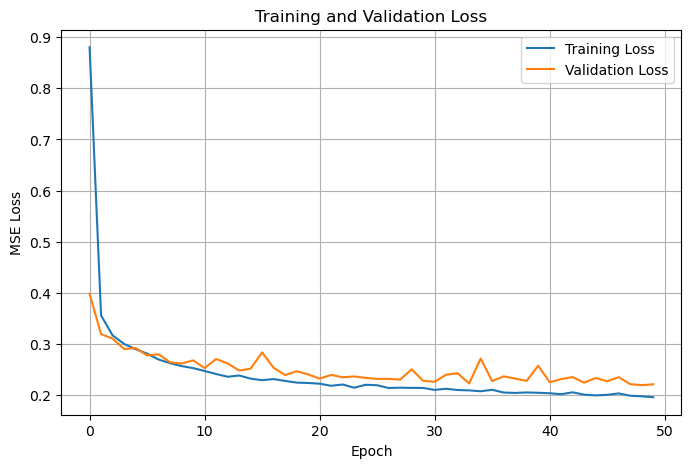

In [27]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# **6. Evaluation on Test Set**

Load the best model and evaluate it on the test set using three common regression metrics:

- **MSE (Mean Squared Error):** Average of squared errors. Penalizes large errors.
- **MAE (Mean Absolute Error):** Average of absolute errors. More interpretable.
- **R² (Coefficient of Determination):** How much variance in the target is explained by the model. R² = 1 is perfect.

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

In [28]:
# Load best model
model.load_state_dict(torch.load('./best_regression_model.pth'))
model.eval()

# Collect all predictions and targets
all_predictions = []
all_targets = []

with torch.no_grad():
    for batch_features, batch_targets in testloader:
        batch_features = batch_features.to(device)
        predictions = model(batch_features).cpu()
        all_predictions.append(predictions)
        all_targets.append(batch_targets)

all_predictions = torch.cat(all_predictions).numpy().flatten()
all_targets = torch.cat(all_targets).numpy().flatten()

# Compute metrics
mse = np.mean((all_predictions - all_targets) ** 2)
mae = np.mean(np.abs(all_predictions - all_targets))
ss_res = np.sum((all_targets - all_predictions) ** 2)
ss_tot = np.sum((all_targets - all_targets.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print(f'Test MSE:  {mse:.4f}')
print(f'Test MAE:  {mae:.4f}')
print(f'Test R²:   {r2:.4f}')

Test MSE:  0.2373
Test MAE:  0.3335
Test R²:   0.7525


# **7. Visualize Predictions**

A scatter plot of predicted vs. actual values is a standard way to assess regression quality. Points close to the diagonal line $y = x$ indicate good predictions.

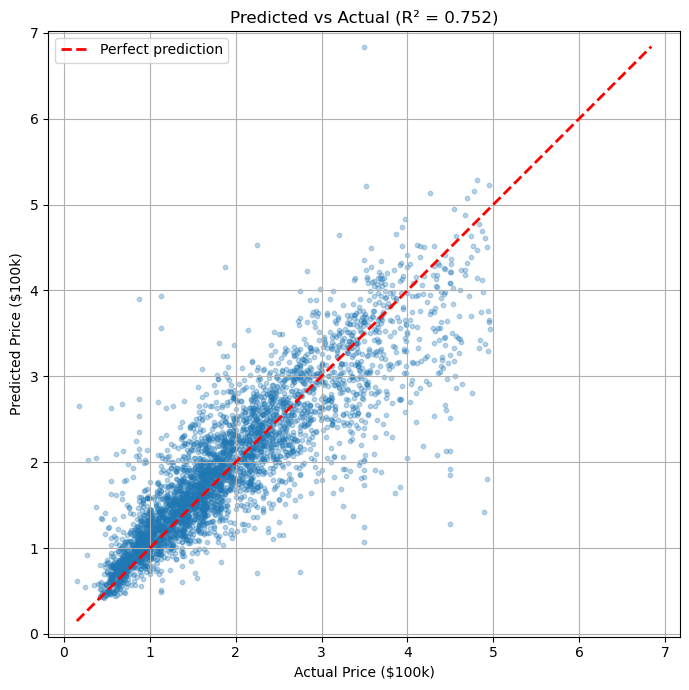

In [29]:
plt.figure(figsize=(7, 7))
plt.scatter(all_targets, all_predictions, alpha=0.3, s=10)
# Plot perfect prediction line
lims = [min(all_targets.min(), all_predictions.min()),
        max(all_targets.max(), all_predictions.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Price ($100k)')
plt.ylabel('Predicted Price ($100k)')
plt.title(f'Predicted vs Actual (R² = {r2:.3f})')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

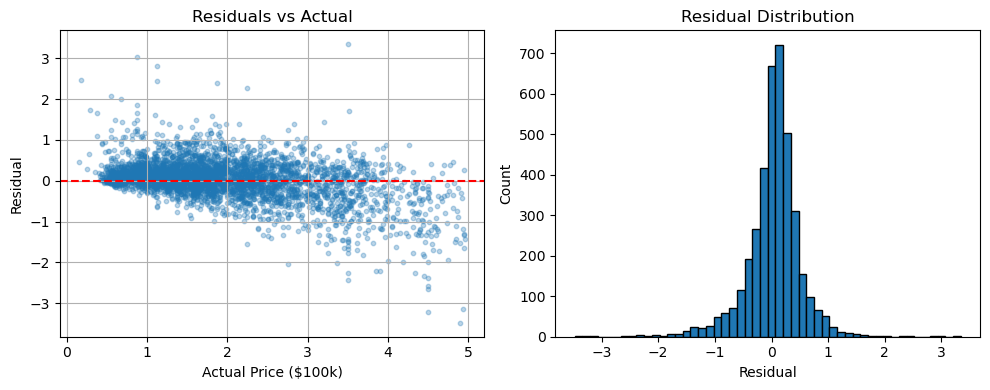

In [30]:
# Plot residuals (prediction errors)
residuals = all_predictions - all_targets

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(all_targets, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Price ($100k)')
plt.ylabel('Residual')
plt.title('Residuals vs Actual')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()

# **8. Questions**

1. What happens if you **don't standardize** the input features? Try it and observe the effect on training.

2. How does the model perform if you use **SGD** instead of **Adam**? What learning rate works best?

3. Experiment with the network architecture: try adding/removing layers, or changing the number of neurons. How does it affect the R² score?

4. What do the residual plots tell you about the model's performance? Are there patterns in the errors?